# 06 — Whole-ROI Kinetic Model Fitting

This notebook fits DCE-MRI pharmacokinetic models to a whole-ROI mean concentration curve.

Instead of fitting each voxel independently, the signal across all ROI voxels is pooled
into a single mean curve and the kinetic model is fit to that curve.

**Contents**
1. Setup and data loading
2. ROI inspection - visual check for file uploads and correct masking
3. AIF inspection - computes AIF concentration time curve and visual check
4. Lesion aggregation — computes lesion concentration and visual check
5. Model fitting with AIF time delay — continuous optimisation


## 1. Setup and data loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from dce_mri.config import (
    AcquisitionConfig, SubjectConfig,
    FittingConfig, RoiFittingConfig,
    AifConfig
)

from dce_mri.kinetic_models import TCXM, GKM, tcxm_ct_analytic, gkm_ct
from dce_mri.signal_models import (
    signal_to_concentration, concentration_to_signal, shift_aif, extract_aif
)
from dce_mri.fitting_roi import (
    fit_roi,
    fit_roi_with_delay_grid,
    fit_roi_with_delay_continuous,
    fit_multi_roi,
    _aggregate_roi_signal,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ──: change parameters ──────────

acq     = AcquisitionConfig(TR=3.64, FA=10.0, r1=3.8,nbase=slice(0,2)) #nbase will change with spokes_per_frame
subject = SubjectConfig("test", T10=1530.0, B1=1.0)
cfg     = FittingConfig(n_lhs=200, n_top=10)
spokes_per_frame = 34

# ──: load real data ─────────────
#  edit these for each subject/dataset you load 
from dce_mri.volume import load_nifti_canonical
from dce_mri.io import load_aif
    
DCE_PATH  = "/mnt/winshare/Labspace/Projects/fastMRIbreast/FMB_34spf_PCA_NII/FMB056/NIfTI/MGRASP_temptv_FMB056_lambda_0_001.nii.gz"
AIF_PATH  = "/mnt/winshare/Labspace/Projects/fastMRIbreast/Lesion_nii_Files/Lesions_nii/FMB056ROI/ROI/56_Aorta_RotOrtho_6.nii"
MASK_PATH = "/mnt/winshare/Labspace/Projects/fastMRIbreast/Lesion_nii_Files/Lesions_nii/FMB056ROI/ROI/56_Lesion 3_RotOrtho_6.nii"
    
subject = SubjectConfig(
    subject_id         = "FMB056",
    T10                = 1530.0,
    B1                 = 1.0,
    dce_path_override  = DCE_PATH,
    aif_path_override   = AIF_PATH,
    mask_path_override  = MASK_PATH,
)
    
sig_4d, ref_img = load_nifti_canonical(subject.dce_path)

# Time parameters
nspoke    = 288    # total spokes across the whole scan
scantime  = 150     # total scan duration, seconds
spoke_res = spokes_per_frame     # spokes per frame, change per case

dt = scantime * spoke_res / nspoke
t = (np.arange(sig_4d.shape[-1])) * dt
    
# load masks — binary ROI
mask_aif,_      = load_nifti_canonical(subject.aif_path)
aif_ROI         = mask_aif.astype(bool)
mask_data, _ = load_nifti_canonical(subject.mask_path)
lesion_ROI   = mask_data.astype(bool)
    
# optional: load segmentation for multi-ROI fitting
# seg_vol, _ = load_nifti_canonical(subject.seg_path)

print(f"Loaded: {sig_4d.shape} volume, {lesion_ROI.sum()} tumor voxels, {aif_ROI.sum()} aif voxels")


Loaded: (320, 320, 192, 8) volume, 441 tumor voxels, 198 aif voxels


# 2. ROI inspection

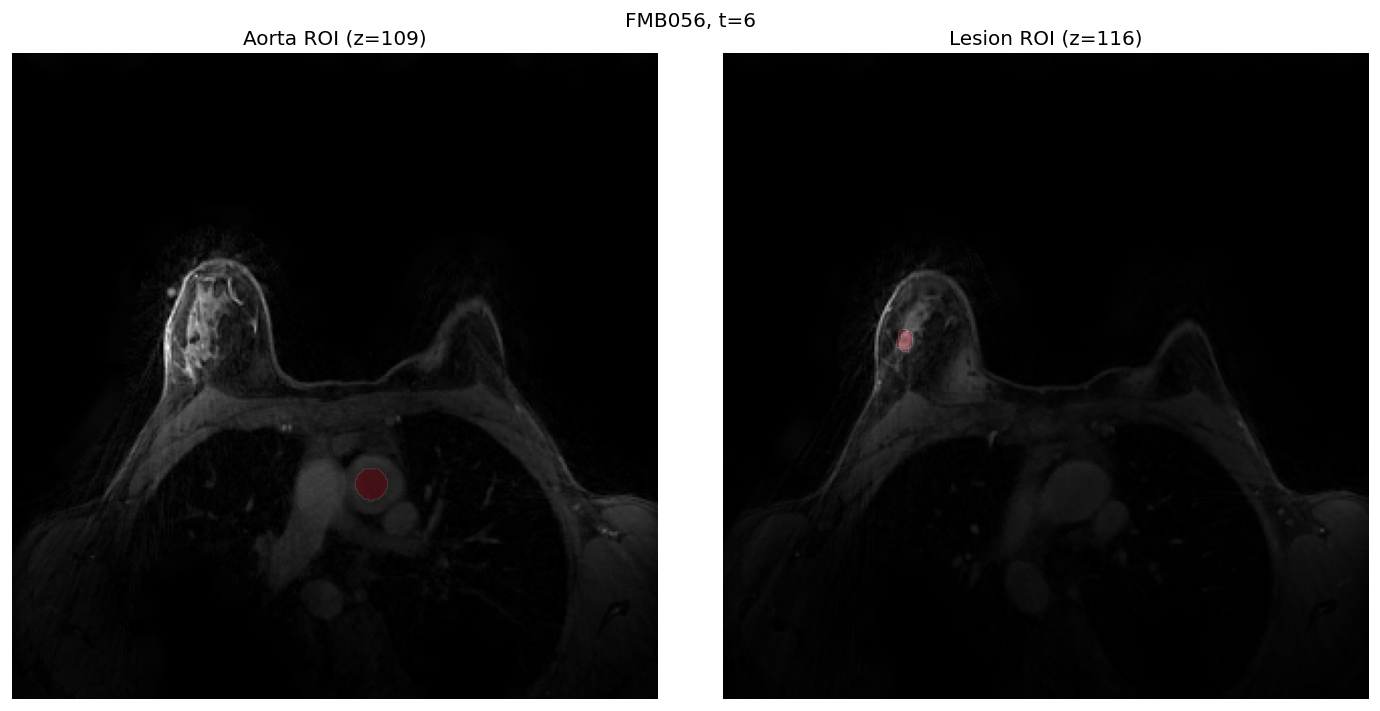

In [3]:
# ──: change indexing based on ROI ──────────
aif_idx = 109 
lesion_idx =116
time_idx = 6
    
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
img_aif = sig_4d[:, :, aif_idx, time_idx]
img_lesion = sig_4d[:, :, lesion_idx, time_idx]
  
axes[0].imshow(img_aif.T, cmap="gray", origin="lower")
axes[0].imshow(aif_ROI[:,:,aif_idx].T,cmap="Reds", alpha= 0.5 * aif_ROI[:,:,aif_idx].T ,origin="lower")
axes[0].set_title(f"Aorta ROI (z={aif_idx})")
axes[0].axis("off")

axes[1].imshow(img_lesion.T,cmap="gray", origin="lower")
axes[1].imshow(lesion_ROI[:,:,lesion_idx].T,cmap="Reds",alpha=0.5 * lesion_ROI[:,:,lesion_idx].T ,origin="lower")
axes[1].set_title(f"Lesion ROI (z={lesion_idx})")
axes[1].axis("off")
    
plt.suptitle(f"{subject.subject_id}, t={time_idx}")
plt.tight_layout()
plt.show()

## 3. AIF time intensity curve inspection

AIF signal range : [10.0, 49.6]
AIF plasma range : [-0.0041, 2.8549] mM


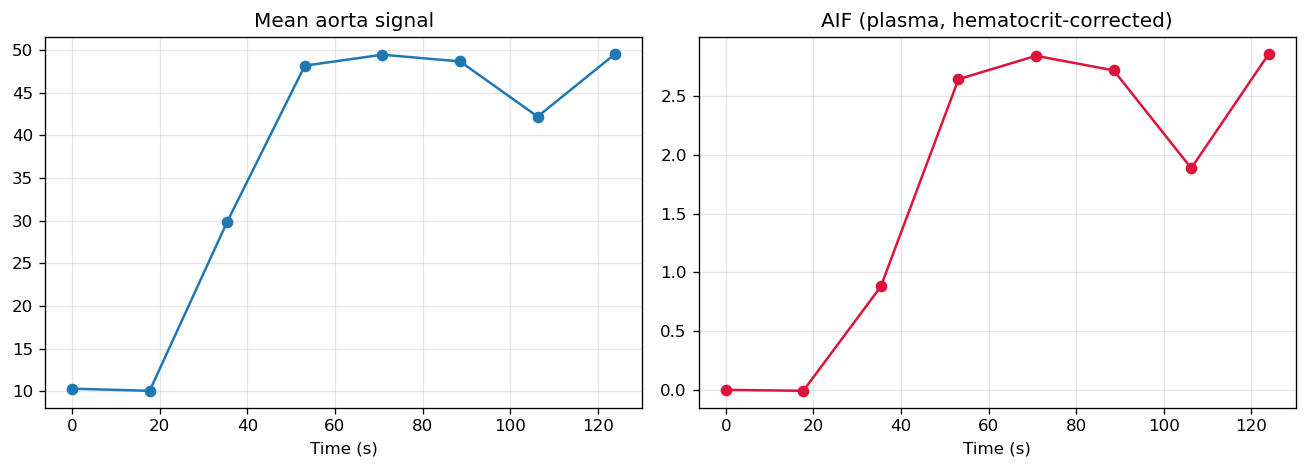

AIF peak time  : 124.0 s
AIF peak value : 2.8549 mM
AIF baseline   : 0.000007 mM


In [4]:
from dce_mri.config import AifConfig
from dce_mri.signal_models import extract_aif

aif_cfg = AifConfig(
    T10        = 1664.0,
    hematocrit = 0.45,
    top_frac   = 1.0,
    nbase      = acq.nbase,
)

aif, aif_signal = extract_aif(sig_4d, aif_ROI, acq, aif_cfg, B1=subject.B1)

print(f"AIF signal range : [{aif_signal.min():.1f}, {aif_signal.max():.1f}]")
print(f"AIF plasma range : [{aif.min():.4f}, {aif.max():.4f}] mM")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, aif_signal, 'o-')
axes[0].set_title("Mean aorta signal")
axes[0].set_xlabel("Time (s)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, aif, 'o-', color='crimson')
axes[1].set_title("AIF (plasma, hematocrit-corrected)")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"AIF peak time  : {t[np.argmax(aif)]:.1f} s")
print(f"AIF peak value : {aif.max():.4f} mM")
print(f"AIF baseline   : {aif[acq.nbase].mean():.6f} mM")

## 4. Lesion time intensity curve inspection

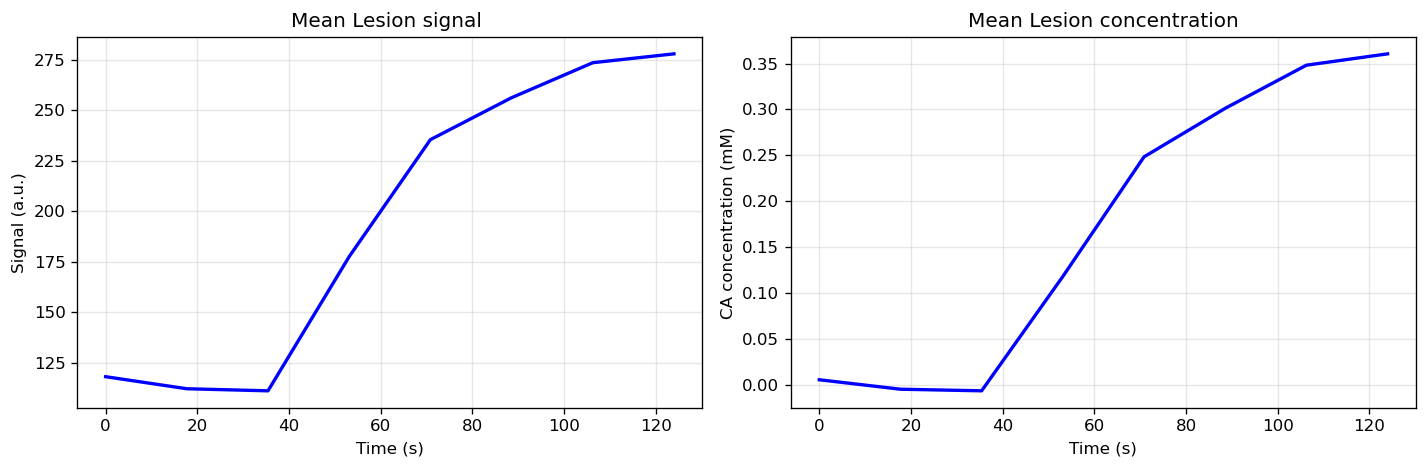

Signal aggregation   : 441 voxels
  Ct range: [-0.0069, 0.3606] mM
  St range: [111.1, 278.0] a.u.


In [5]:
roi_cfg_sig  = RoiFittingConfig(average_space='signal')
roi_cfg_conc = RoiFittingConfig(average_space='concentration')

Ct_sig,  n_sig,  St_sig  = _aggregate_roi_signal(
    sig_4d, lesion_ROI, acq, subject, roi_cfg_sig
)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# signal space
axes[0].plot(t, St_sig,  'b-', lw=2)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Signal (a.u.)')
axes[0].set_title('Mean Lesion signal ')
axes[0].grid(True, alpha=0.3)

# concentration space
axes[1].plot(t, Ct_sig,  'b-', lw=2)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('CA concentration (mM)')
axes[1].set_title('Mean Lesion concentration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Signal aggregation   : {n_sig} voxels")
print(f"  Ct range: [{Ct_sig.min():.4f}, {Ct_sig.max():.4f}] mM")
print(f"  St range: [{St_sig.min():.1f}, {St_sig.max():.1f}] a.u.")

## 5. Model fitting with AIF time delay — continuous optimisation

Continuous tau bounds: [-10.0, 40.0] s

Fitting TCXM + continuous delay ...

── TCXM + continuous delay ───────────────────────
  success      : True
  cost         : 5.6390e-04
  best tau     : 11.684 s
  ve      : 0.50000
  vp      : 0.06164
  fp      : 0.04167
  ps      : 0.00135


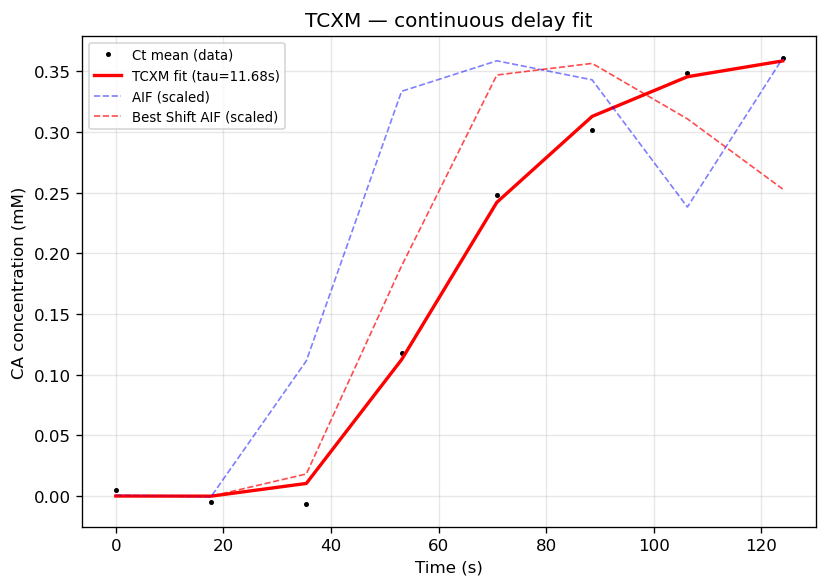

In [6]:
# tau bounds — adjust based on your data and expected delay range
TAU_LB = -10.0   # s
TAU_UB =  40.0   # s 
TAU_P0 =   0.0   # s — initial guess

roi_cfg = RoiFittingConfig(average_space='signal')
print(f"Continuous tau bounds: [{TAU_LB}, {TAU_UB}] s")

print("\nFitting TCXM + continuous delay ...")
result_tcxm_cont = fit_roi_with_delay_continuous(
    sig_4d, lesion_ROI, aif, t, TCXM, acq, subject, cfg, roi_cfg,
    tau_lb=TAU_LB, tau_ub=TAU_UB, tau_p0=TAU_P0, seed=0, 
    interp_method="pchip"
)

print("\n── TCXM + continuous delay ───────────────────────")
print(f"  success      : {result_tcxm_cont.success}")
print(f"  cost         : {result_tcxm_cont.best_cost:.4e}")
print(f"  best tau     : {result_tcxm_cont.best_tau:.3f} s")
for name, val in zip(TCXM.param_names, result_tcxm_cont.best_params):
    print(f"  {name:8s}: {val:.5f}")

# plot continuous delay fit
Ct_sig_mean = _aggregate_roi_signal(sig_4d, lesion_ROI, acq, subject, roi_cfg)[0]

shifted_aif_best = shift_aif(aif, result_tcxm_cont.best_tau, t, acq, method="pchip")
Ct_pred_best     = TCXM.fn(result_tcxm_cont.best_params, t, shifted_aif_best)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t, Ct_sig_mean, 'k.', ms=4, label='Ct mean (data)')
ax.plot(t, Ct_pred_best, 'r-', lw=2,
        label=f'TCXM fit (tau={result_tcxm_cont.best_tau:.2f}s)')
ax.plot(t, aif * Ct_sig_mean.max() / aif.max(),
        'b--', lw=1, alpha=0.5, label='AIF (scaled)')
ax.plot(t, shifted_aif_best * Ct_sig_mean.max() / aif.max(),
        'r--', lw=1, alpha=0.7, label='Best Shift AIF (scaled)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('CA concentration (mM)')
ax.set_title('TCXM — continuous delay fit')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()